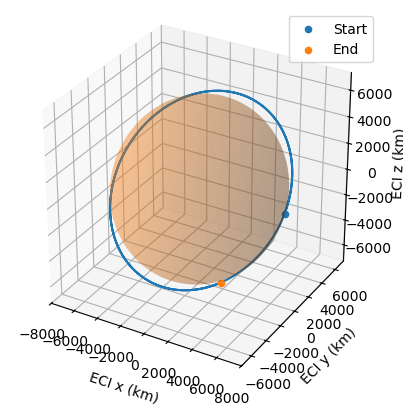

In [1]:
from datetime import datetime, timezone, timedelta
from orbit import simulation_config, propagate_orbit
from constants import EARTH_MU_m3_s2
import matplotlib.pyplot as plt
import numpy as np

# Setting up constants and initial conditions
propagation_method = "cowell"  # either "cowell" or "encke" for now
mu = EARTH_MU_m3_s2
r0 = 7000e3
v0 = np.sqrt(mu / r0 / 2)

x0 = np.array([
    r0, 0, 0,
    0, v0, v0
])

t0 = datetime(2026, 9, 4, 0, 0, 0,tzinfo=timezone.utc)
tf = t0 + timedelta(minutes=180)
config = simulation_config(
    t0=t0,
    tf=tf,
    time_steps=1800,
    propagator_method=propagation_method,
    x0=x0,
    drag=False,
    J2=False
)

# running propagation
states = propagate_orbit(config)
x = states[0, :] / 1000
y = states[1, :] / 1000
z = states[2, :] / 1000

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plotting orbit
ax.plot(x, y, z)
ax.scatter(x[0], y[0], z[0],label="Start")
ax.scatter(x[-1], y[-1], z[-1], label="End")

# Drawing up the earth
R_earth = 6371
longitudes = np.linspace(0, 2 * np.pi, 100)
latitudes = np.linspace(0, np.pi, 100)
x_earth = R_earth * np.outer(np.cos(longitudes), np.sin(latitudes))
y_earth = R_earth * np.outer(np.sin(longitudes), np.sin(latitudes))
z_earth = R_earth * np.outer(np.ones_like(longitudes), np.cos(latitudes))
ax.plot_surface(x_earth, y_earth, z_earth, alpha=0.25)

ax.set_xlabel("ECI x (km)")
ax.set_ylabel("ECI y (km)")
ax.set_zlabel("ECI z (km)")
ax.set_box_aspect([1, 1, 1])
ax.legend()
plt.show()